# Integrated deterministic sensitivity synthesis

This notebook synthesizes five controlled one-factor-at-a-time analyses:

1. Hole diameter.
2. Uniaxial compressive strength.
3. Explosive density.
4. Rock density.
5. Ash burden ratio.

The analyses use different units, grids, empirical domains, and model-response structures. Their sampled changes must not be interpreted as a universal ranking of parameter importance, predictive uncertainty, or engineering significance.

**Decision gate:** `RESEARCH_COMPARATOR_ONLY`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

from blastdesign import (
    build_integrated_sensitivity_summary,
    build_model_parameter_dependency_matrix,
)

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIRECTORY = PROJECT_ROOT / "data" / "processed"
FIGURE_DIRECTORY = PROJECT_ROOT / "outputs" / "figures"

DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

## Method

The synthesis regenerates all five deterministic sensitivity analyses using their documented default grids.

The integrated summary records the sampled minimum, reference, and maximum seven-model ranges. The dependency matrix records whether each reconstructed equation changes numerically somewhere on each sampled grid.

A positive dependency means only that the implemented equation responds to that parameter. It does not demonstrate field importance, causal influence, predictive accuracy, or independent validation.

In [2]:
integrated_summary = build_integrated_sensitivity_summary()
dependency_matrix = build_model_parameter_dependency_matrix()

integrated_summary.to_csv(
    DATA_DIRECTORY / "integrated_sensitivity_summary.csv",
    index=False,
)

dependency_matrix.to_csv(
    DATA_DIRECTORY / "model_parameter_dependency_matrix.csv",
    index=False,
)

display(integrated_summary)
display(dependency_matrix)

,analysis_id,parameter_name,parameter_label,unit,reference_value,sampled_minimum,sampled_maximum,sample_count,responding_model_count,responding_model_ids_json,reference_mean_burden_m,reference_range_m,minimum_ensemble_range_m,minimum_range_parameter_values_json,maximum_ensemble_range_m,maximum_range_parameter_values_json,ensemble_range_span_m
0,diameter,hole_diameter_mm,Hole diameter,mm,251.00,181.0,311.0,14,7,"[""CONV_ASH"", ""CONV_BHANDARI"", ""CONV_JIMENO"", ""...",6.137371,1.455865,1.394229,[271.0],1.722230,[311.0],0.328001
1,ucs,ucs_mpa,Uniaxial compressive strength,MPa,85.00,40.0,220.0,11,2,"[""CONV_JIMENO"", ""CONV_TATIYA""]",6.137371,1.455865,1.455865,"[70.0, 85.0, 110.0]",1.894109,"[110.001, 180.0, 180.001, 220.0]",0.438244
2,explosive_density,explosive_density_g_cm3,Explosive density,g/cm3,0.85,0.7,1.0,7,2,"[""CONV_KONYA_1972"", ""CONV_KONYA_1983""]",6.137371,1.455865,1.210189,[1.0],1.798902,[0.7],0.588713
3,rock_density,rock_density_g_cm3,Rock density,g/cm3,4.37,1.8,5.3,12,2,"[""CONV_KONYA_1972"", ""CONV_KONYA_1983""]",6.137371,1.455865,1.210189,"[2.4, 2.6, 2.75, 3.0, 3.3, 3.75]",1.796828,[5.3],0.586639
4,ash_burden_ratio,ash_burden_ratio,Ash burden ratio,dimensionless,25.00,20.0,40.0,9,1,"[""CONV_ASH""]",6.137371,1.455865,1.455865,"[22.5, 25.0, 27.5]",4.512676,[40.0],3.056811


,model_id,model_name,hole_diameter_mm,ucs_mpa,explosive_density_g_cm3,rock_density_g_cm3,ash_burden_ratio,responsive_parameter_count
0,CONV_ASH,Ash,True,False,False,False,True,2
1,CONV_BHANDARI,Bhandari,True,False,False,False,False,1
2,CONV_JIMENO,Lopez Jimeno,True,True,False,False,False,2
3,CONV_KONYA_1972,Konya 1972,True,False,True,True,False,3
4,CONV_KONYA_1983,Konya 1983,True,False,True,True,False,3
5,CONV_RUSTAN,Rustan,True,False,False,False,False,1
6,CONV_TATIYA,Tatiya–Al-Ajmi,True,True,False,False,False,2


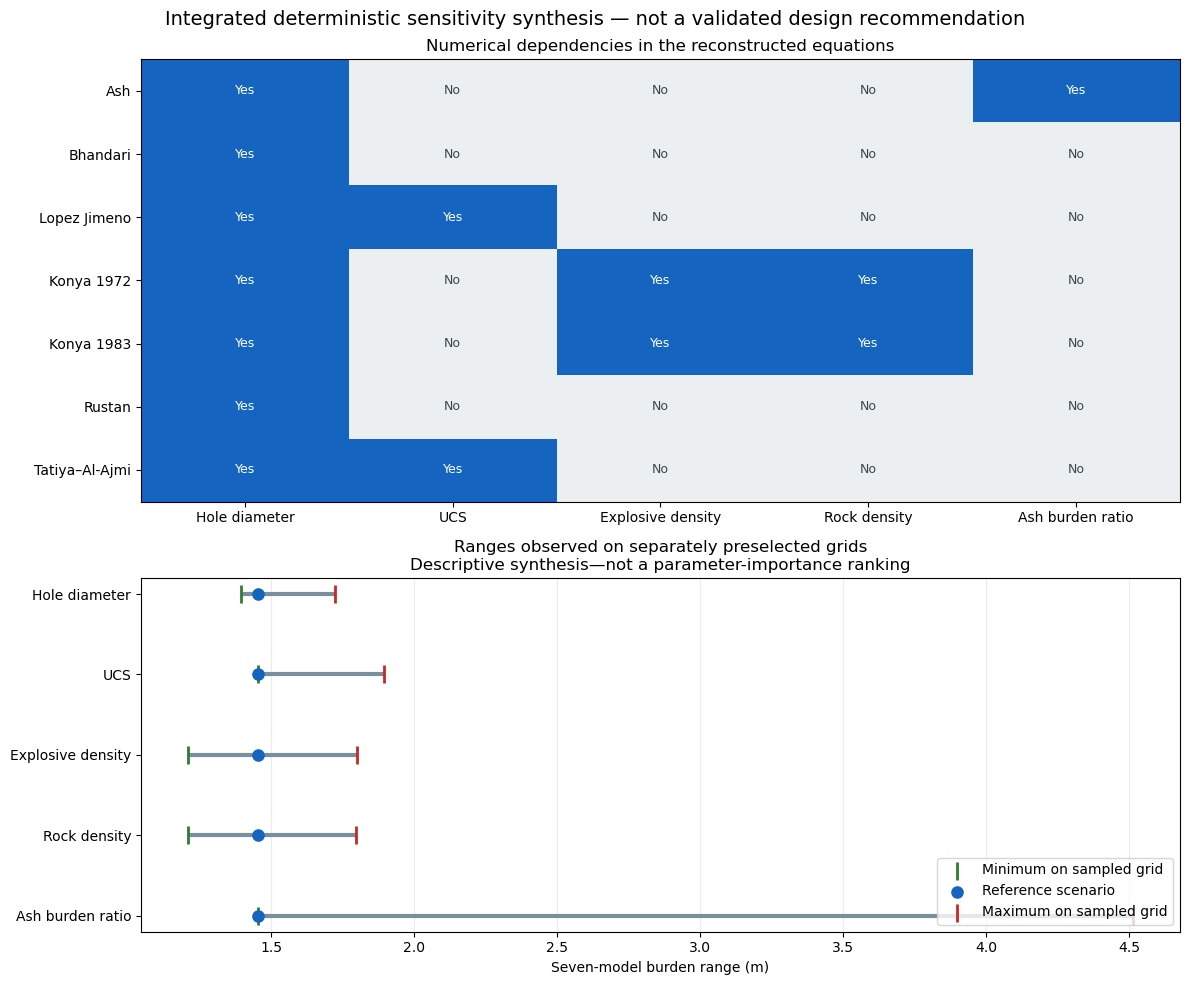

Saved figure: C:\Users\A.Mehregan\Projects\BlastDesign-AI\outputs\figures\integrated_sensitivity_synthesis.png


In [3]:
parameter_columns = [
    "hole_diameter_mm",
    "ucs_mpa",
    "explosive_density_g_cm3",
    "rock_density_g_cm3",
    "ash_burden_ratio",
]

parameter_labels = [
    "Hole diameter",
    "UCS",
    "Explosive density",
    "Rock density",
    "Ash burden ratio",
]

response_values = (
    dependency_matrix[parameter_columns]
    .astype(int)
    .to_numpy()
)

figure, axes = plt.subplots(
    2,
    1,
    figsize=(12, 10),
    gridspec_kw={"height_ratios": [1.25, 1.0]},
)

response_colormap = ListedColormap(
    ["#eceff1", "#1565c0"]
)

axes[0].imshow(
    response_values,
    cmap=response_colormap,
    aspect="auto",
    vmin=0,
    vmax=1,
)

axes[0].set_xticks(
    np.arange(len(parameter_labels)),
    labels=parameter_labels,
)

axes[0].set_yticks(
    np.arange(len(dependency_matrix)),
    labels=dependency_matrix["model_name"],
)

axes[0].set_title(
    "Numerical dependencies in the reconstructed equations"
)

for row_index in range(response_values.shape[0]):
    for column_index in range(response_values.shape[1]):
        responds = bool(
            response_values[row_index, column_index]
        )

        axes[0].text(
            column_index,
            row_index,
            "Yes" if responds else "No",
            ha="center",
            va="center",
            color="white" if responds else "#37474f",
            fontsize=9,
        )

plot_summary = integrated_summary.copy()

analysis_labels = {
    "diameter": "Hole diameter",
    "ucs": "UCS",
    "explosive_density": "Explosive density",
    "rock_density": "Rock density",
    "ash_burden_ratio": "Ash burden ratio",
}

plot_summary["plot_label"] = (
    plot_summary["analysis_id"].map(analysis_labels)
)

y_positions = np.arange(len(plot_summary))

minimum_ranges = (
    plot_summary["minimum_ensemble_range_m"].to_numpy()
)

reference_ranges = (
    plot_summary["reference_range_m"].to_numpy()
)

maximum_ranges = (
    plot_summary["maximum_ensemble_range_m"].to_numpy()
)

axes[1].hlines(
    y_positions,
    minimum_ranges,
    maximum_ranges,
    color="#78909c",
    linewidth=3,
)

axes[1].scatter(
    minimum_ranges,
    y_positions,
    marker="|",
    s=180,
    linewidths=2,
    color="#2e7d32",
    label="Minimum on sampled grid",
    zorder=3,
)

axes[1].scatter(
    reference_ranges,
    y_positions,
    marker="o",
    s=65,
    color="#1565c0",
    label="Reference scenario",
    zorder=4,
)

axes[1].scatter(
    maximum_ranges,
    y_positions,
    marker="|",
    s=180,
    linewidths=2,
    color="#c62828",
    label="Maximum on sampled grid",
    zorder=3,
)

axes[1].set_yticks(
    y_positions,
    labels=plot_summary["plot_label"],
)

axes[1].invert_yaxis()

axes[1].set_xlabel(
    "Seven-model burden range (m)"
)

axes[1].set_title(
    "Ranges observed on separately preselected grids\n"
    "Descriptive synthesis—not a parameter-importance ranking"
)

axes[1].grid(
    axis="x",
    alpha=0.25,
)

axes[1].legend(
    loc="lower right",
)

figure.suptitle(
    "Integrated deterministic sensitivity synthesis — "
    "not a validated design recommendation",
    fontsize=14,
)

figure.tight_layout()

figure_path = (
    FIGURE_DIRECTORY
    / "integrated_sensitivity_synthesis.png"
)

figure.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:", figure_path)

## Interpretation

All five analyses reproduce the same seven-model burden range at the reconstructed reference scenario.

The dependency matrix describes the mathematical behavior of the currently implemented equations:

- All seven equations respond to hole diameter.
- López Jimeno and Tatiya–Al-Ajmi respond to UCS.
- Konya 1972 and Konya 1983 respond to explosive density and rock density.
- Only Ash responds to the implemented Ash burden-ratio coefficient.

The lower panel summarizes the minimum, reference, and maximum model ranges observed on five separately selected grids. Differences between these spans must not be interpreted as a global sensitivity ranking because the parameters use different units, intervals, empirical classifications, and equation structures.

The synthesis does not provide calibrated uncertainty, predictive accuracy, parameter importance, optimization, or a field-ready blast-design recommendation.